# Released ResNet-18 baseline (local-data version)

This is the course-released ResNet-18 + 2-D MSE regression baseline, ported off of HuggingFace + Colab so it trains on **our collected data** (`Img2GPS/metadata.csv`, 89 phone photos) and validates on the **course reference set** (`Img2GPS/reference/metadata.csv`, 6 photos) — the exact same data path used in `img2gps.ipynb`.

Architecture is **unchanged** from the release: ImageNet ResNet-18 backbone with the final FC layer swapped for a 2-output head, MSE loss in standardized lat/lon space, Adam + StepLR, photometric + flip + rotation augmentation. The point of this notebook is to give us a baseline number from the released recipe, run on our actual data and validated on the course reference set.

## 0. Bootstrap (Colab + local)

Same logic as `img2gps.ipynb` cell 2: in Colab, clone the repo into `/content/cis_5190_project` and `pip install -r requirements.txt`. Locally, walk up the directory tree to find the repo root. Either way, after this cell `cwd == repo_root`, the `Img2GPS/` package is on `sys.path`, and `preprocess`, `model`, `train` are importable — the same image-loading path `img2gps.ipynb` uses, so any difference between the two notebooks is the model, not the data.

In [13]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/SheilaBkny/cis_5190_project.git'
REPO_BRANCH = 'iter2'
COLAB_REPO_DIR = '/content/cis_5190_project'

IN_COLAB = 'google.colab' in sys.modules

def _git(*args):
    subprocess.run(['git', '-C', COLAB_REPO_DIR, *args], check=True)

if IN_COLAB:
    if not os.path.exists(os.path.join(COLAB_REPO_DIR, 'Img2GPS')):
        subprocess.run(['git', 'clone', '--branch', REPO_BRANCH, REPO_URL, COLAB_REPO_DIR], check=True)
    else:
        _git('fetch', 'origin', REPO_BRANCH)
        _git('checkout', REPO_BRANCH)
        _git('reset', '--hard', f'origin/{REPO_BRANCH}')
    os.chdir(COLAB_REPO_DIR)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'geopy'], check=True)
    head = subprocess.check_output(['git', '-C', COLAB_REPO_DIR, 'log', '-1', '--oneline']).decode().strip()
    print(f'on commit: {head}')

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while REPO_ROOT.name and not (REPO_ROOT / 'Img2GPS').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'Img2GPS').exists():
    raise RuntimeError(f'could not locate Img2GPS/ from cwd={Path.cwd()}; bootstrap failed')
PROJECT_DIR = REPO_ROOT / 'Img2GPS'
sys.path.insert(0, str(PROJECT_DIR))
os.chdir(REPO_ROOT)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('torch     :', torch.__version__)
print('device    :', device)
print('repo root :', REPO_ROOT)
print('project   :', PROJECT_DIR)

on commit: ecffbe9 k-means 80
torch     : 2.10.0+cu128
device    : cuda
repo root : /content/cis_5190_project
project   : /content/cis_5190_project/Img2GPS


## 1. Data

We load the same CSVs `img2gps.ipynb` uses, via the project's `preprocess.load_raw` (`(N, 3, 224, 224)` images in `[0, 1]` + raw lat/lon). Augmentation and ImageNet normalization are applied per-batch in this notebook so the released training-time augmentation pipeline is preserved.

In [14]:
from preprocess import load_raw  # noqa: E402

TRAIN_CSV = str(PROJECT_DIR / 'metadata.csv')
REF_CSV = str(PROJECT_DIR / 'reference' / 'metadata.csv')

X_train_raw, y_train = load_raw(TRAIN_CSV)
X_ref_raw, y_ref = load_raw(REF_CSV)

print(f'collected (train)  : {tuple(X_train_raw.shape)}  labels {tuple(y_train.shape)}')
print(f'reference (val)    : {tuple(X_ref_raw.shape)}  labels {tuple(y_ref.shape)}')
print()
print('train CSV head:')
print(pd.read_csv(TRAIN_CSV).head(3).to_string(index=False))
print()
print('reference CSV:')
print(pd.read_csv(REF_CSV).to_string(index=False))

collected (train)  : (89, 3, 224, 224)  labels (89, 2)
reference (val)    : (6, 3, 224, 224)  labels (6, 2)

train CSV head:
                        image_path  latitude  longitude
data/images_converted/IMG_0210.png 39.951408 -75.190588
data/images_converted/IMG_0211.png 39.951408 -75.190588
data/images_converted/IMG_0212.png 39.951408 -75.190588

reference CSV:
   file_name  Latitude  Longitude
IMG_7171.jpg 39.952308 -75.191575
IMG_7175.jpg 39.952325 -75.191581
IMG_7163.jpg 39.952300 -75.191550
IMG_7159.jpg 39.952300 -75.191550
IMG_7170.jpg 39.952308 -75.191575
IMG_7165.jpg 39.952300 -75.191550


## 2. Custom Dataset class

Same shape as the released `GPSImageDataset`: returns `(image, [lat_norm, lon_norm])` per item, with lat/lon **standardized using the training-set mean/std** (computed once from the collected data and reused on the reference set, so val coordinates are normalized with the same stats as training).

In [15]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset


class LocalGPSImageDataset(Dataset):
    """Drop-in replacement for the released GPSImageDataset.

    Backed by a tensor of pre-resized [0, 1] images (from preprocess.load_raw)
    plus raw [lat, lon] labels. Returns standardized labels using train mean/std.
    """

    def __init__(self, X_raw, y_raw, transform=None,
                 lat_mean=None, lat_std=None, lon_mean=None, lon_std=None):
        self.X_raw = X_raw
        self.y_raw = y_raw
        self.transform = transform

        lats = y_raw[:, 0].numpy()
        lons = y_raw[:, 1].numpy()
        self.latitude_mean = float(lat_mean) if lat_mean is not None else float(np.mean(lats))
        self.latitude_std = float(lat_std) if lat_std is not None else float(np.std(lats))
        self.longitude_mean = float(lon_mean) if lon_mean is not None else float(np.mean(lons))
        self.longitude_std = float(lon_std) if lon_std is not None else float(np.std(lons))
        self.latitude_std = max(self.latitude_std, 1e-8)
        self.longitude_std = max(self.longitude_std, 1e-8)

    def __len__(self):
        return self.X_raw.shape[0]

    def __getitem__(self, idx):
        image = self.X_raw[idx]  # (3, 224, 224) in [0, 1]
        if self.transform is not None:
            image = self.transform(image)
        lat = (float(self.y_raw[idx, 0]) - self.latitude_mean) / self.latitude_std
        lon = (float(self.y_raw[idx, 1]) - self.longitude_mean) / self.longitude_std
        return image, torch.tensor([lat, lon], dtype=torch.float32)


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

inference_transform = transforms.Compose([
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = LocalGPSImageDataset(X_train_raw, y_train, transform=train_transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

lat_mean = train_dataset.latitude_mean
lat_std = train_dataset.latitude_std
lon_mean = train_dataset.longitude_mean
lon_std = train_dataset.longitude_std

val_dataset = LocalGPSImageDataset(
    X_ref_raw, y_ref, transform=inference_transform,
    lat_mean=lat_mean, lat_std=lat_std,
    lon_mean=lon_mean, lon_std=lon_std,
)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f'train dataset: {len(train_dataset)} examples')
print(f'val   dataset: {len(val_dataset)} examples (reference set)')
print(f'train target stats: lat={lat_mean:.6f}±{lat_std:.6f}  lon={lon_mean:.6f}±{lon_std:.6f}')

train dataset: 89 examples
val   dataset: 6 examples (reference set)
train target stats: lat=39.951565±0.000251  lon=-75.191322±0.000548


In [16]:
for images, gps_coords in train_dataloader:
    print('batch images :', tuple(images.shape))
    print('batch labels :', tuple(gps_coords.shape))
    print('label range  :', gps_coords.min().item(), gps_coords.max().item())
    break

batch images : (32, 3, 224, 224)
batch labels : (32, 2)
label range  : -1.9893460273742676 2.1867620944976807


### Quick visualization (a couple training images)

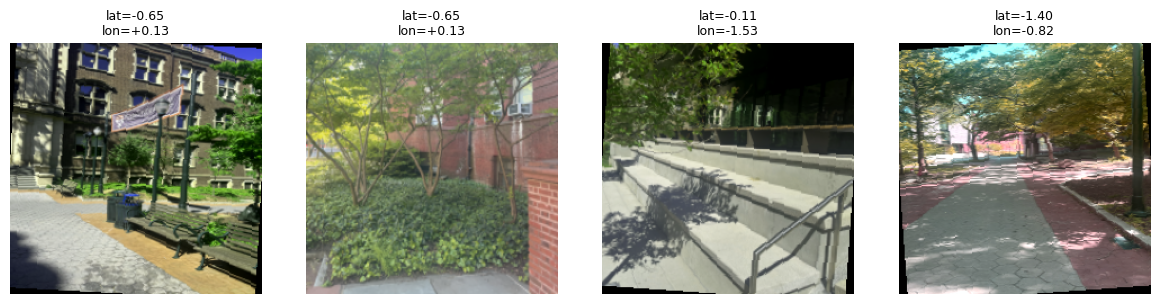

In [17]:
import matplotlib.pyplot as plt

def denormalize(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    arr = t.cpu().numpy().transpose(1, 2, 0)
    arr = np.array(std) * arr + np.array(mean)
    return np.clip(arr, 0, 1)

data_iter = iter(train_dataloader)
imgs, coords = next(data_iter)
fig, axes = plt.subplots(1, min(4, imgs.shape[0]), figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(denormalize(imgs[i]))
    ax.set_title(f'lat={coords[i, 0].item():+.2f}\nlon={coords[i, 1].item():+.2f}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. ResNet-18 baseline

Same setup as the release: ImageNet-pretrained ResNet-18, final FC swapped for a 2-output regression head, full-network fine-tuning, MSE loss in standardized space, Adam (`lr=1e-3`), `StepLR(step_size=5, gamma=0.1)`. We train on the collected data and report Haversine on the reference set after every epoch (since it's our actual val set).

In [18]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from geopy.distance import geodesic
from torch.optim.lr_scheduler import StepLR

torch.manual_seed(42)

try:
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    resnet = models.resnet18(weights=None)
    print('warning: could not download ImageNet weights, training from scratch')
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 2)

for param in resnet.parameters():
    param.requires_grad = True

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

resnet = resnet.to(device)

# Snapshot of the best (lowest reference-set Haversine) state. The release
# recipe is fully fine-tuning ResNet-18 at lr=1e-3 on ~89 images, which can
# diverge to NaN under Adam. We add (1) gradient clipping, (2) skip-on-NaN,
# (3) keep the best checkpoint so a late blow-up does not destroy the run.
best_val_mean = float('inf')
best_state = None
best_epoch = -1

num_epochs = 10
history = []
for epoch in range(num_epochs):
    resnet.train()
    running_loss = 0.0
    n_batches = 0
    n_skipped = 0
    for images, gps_coords in train_dataloader:
        images = images.to(device)
        gps_coords = gps_coords.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, gps_coords)
        if not torch.isfinite(loss):
            n_skipped += 1
            optimizer.zero_grad()
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(resnet.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1

    scheduler.step()
    train_loss = running_loss / max(n_batches, 1)

    resnet.eval()
    val_dists = []
    base_dists = []
    with torch.no_grad():
        for images, gps_coords in val_dataloader:
            images = images.to(device)
            outputs = resnet(images)
            preds = outputs.cpu().numpy() * np.array([lat_std, lon_std]) + np.array([lat_mean, lon_mean])
            actuals = gps_coords.numpy() * np.array([lat_std, lon_std]) + np.array([lat_mean, lon_mean])
            for p, a in zip(preds, actuals):
                val_dists.append(geodesic((a[0], a[1]), (p[0], p[1])).meters)
                base_dists.append(geodesic((a[0], a[1]), (lat_mean, lon_mean)).meters)

    val_mean = float(np.mean(val_dists)) if val_dists else float('nan')
    val_p50 = float(np.median(val_dists)) if val_dists else float('nan')
    val_max = float(np.max(val_dists)) if val_dists else float('nan')
    base_mean = float(np.mean(base_dists)) if base_dists else float('nan')

    if np.isfinite(val_mean) and val_mean < best_val_mean:
        best_val_mean = val_mean
        best_state = {k: v.detach().cpu().clone() for k, v in resnet.state_dict().items()}
        best_epoch = epoch + 1

    history.append({'epoch': epoch + 1, 'train_mse': train_loss,
                    'ref_hav_mean_m': val_mean, 'ref_hav_p50_m': val_p50, 'ref_hav_max_m': val_max,
                    'baseline_hav_mean_m': base_mean, 'skipped_batches': n_skipped})
    skip_msg = f' [skipped {n_skipped} non-finite batches]' if n_skipped else ''
    print(f'epoch {epoch + 1:02d}/{num_epochs}  train_mse={train_loss:.4f}  '
          f'ref_hav_mean={val_mean:6.2f}m  p50={val_p50:6.2f}m  max={val_max:6.2f}m  '
          f'(baseline={base_mean:.2f}m){skip_msg}')

if best_state is not None:
    resnet.load_state_dict(best_state)
    print(f'\nrestored best checkpoint from epoch {best_epoch} (ref_hav_mean={best_val_mean:.2f}m)')
else:
    print('\nWARNING: no finite validation metric across the run - ResNet-18 diverged completely.')

# Save under the canonical filename the evaluator (Img2GPS/eval_project_a.py)
# and the spec contract expect. Img2GPS/model.py wraps a torchvision
# resnet18 in self.model so this state_dict loads into it directly.
torch.save(resnet.state_dict(), str(PROJECT_DIR / 'model.pt'))
print('saved ResNet-18 submission checkpoint to Img2GPS/model.pt')
history_df = pd.DataFrame(history)
history_df

epoch 01/10  train_mse=1.5676  ref_hav_mean=103.47m  p50=111.44m  max=167.35m  (baseline=85.00m)
epoch 02/10  train_mse=1.6359  ref_hav_mean=173.72m  p50=159.39m  max=227.67m  (baseline=85.00m)
epoch 03/10  train_mse=1.2096  ref_hav_mean= 40.87m  p50= 31.74m  max= 65.90m  (baseline=85.00m)
epoch 04/10  train_mse=0.9259  ref_hav_mean= 36.44m  p50= 37.46m  max= 47.47m  (baseline=85.00m)
epoch 05/10  train_mse=0.6947  ref_hav_mean= 80.80m  p50= 60.90m  max=168.07m  (baseline=85.00m)
epoch 06/10  train_mse=0.5181  ref_hav_mean= 81.89m  p50= 68.68m  max=132.92m  (baseline=85.00m)
epoch 07/10  train_mse=0.4768  ref_hav_mean= 82.21m  p50= 78.02m  max=108.45m  (baseline=85.00m)
epoch 08/10  train_mse=0.4068  ref_hav_mean= 85.97m  p50= 85.61m  max=101.03m  (baseline=85.00m)
epoch 09/10  train_mse=0.4230  ref_hav_mean= 88.90m  p50= 90.32m  max= 99.04m  (baseline=85.00m)
epoch 10/10  train_mse=0.3068  ref_hav_mean= 89.75m  p50= 91.18m  max= 98.95m  (baseline=85.00m)

restored best checkpoint from

,epoch,train_mse,ref_hav_mean_m,ref_hav_p50_m,ref_hav_max_m,baseline_hav_mean_m,skipped_batches
0,1,1.567606,103.468139,111.440618,167.349407,85.003029,0
1,2,1.635878,173.718224,159.385596,227.665001,85.003029,0
2,3,1.209576,40.867106,31.741390,65.904539,85.003029,0
3,4,0.925859,36.440583,37.458242,47.474957,85.003029,0
4,5,0.694741,80.797631,60.902010,168.068683,85.003029,0
5,6,0.518145,81.891537,68.684996,132.919313,85.003029,0
6,7,0.476812,82.205614,78.020597,108.451429,85.003029,0
7,8,0.406780,85.966771,85.605884,101.028220,85.003029,0
8,9,0.422966,88.901728,90.323583,99.038431,85.003029,0
9,10,0.306838,89.753445,91.181760,98.947098,85.003029,0


## 3.5 Save the trained model to your machine

Mirrors `img2gps.ipynb` §2.5. The training cell above already wrote `Img2GPS/model.pt` (the **best** epoch's weights, restored after training completes). On Colab this lives only inside the runtime VM, so the next cell:

1. Prints the file's size and a short MD5 fingerprint so you can confirm it's the run you just produced.
2. If running in Colab, triggers a browser download.

After the download completes, move `~/Downloads/model.pt` to `Img2GPS/model.pt` in your local clone — this is the file `Img2GPS/model.py`'s `Model()` constructor auto-loads, so once it's in place the model is submission-ready.

In [19]:
import hashlib

MODEL_PATH = str(PROJECT_DIR / 'model.pt')
size_mb = os.path.getsize(MODEL_PATH) / 1e6
md5 = hashlib.md5(open(MODEL_PATH, 'rb').read()).hexdigest()[:12]
print(f'model.pt   size: {size_mb:.1f} MB   md5: {md5}')
if best_epoch >= 0:
    print(f'this checkpoint is from epoch {best_epoch} (ref_hav_mean={best_val_mean:.2f}m on the reference set)')

if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(MODEL_PATH)
    print('Downloaded. Move ~/Downloads/model.pt -> <repo>/Img2GPS/model.pt locally to make the submission ready.')
else:
    print('Not in Colab — model.pt is already on your local filesystem at the path above.')

resnet18_baseline.pth   size: 44.8 MB   md5: 808c9bf92f1c
this checkpoint is from epoch 4 (ref_hav_mean=36.44m on the reference set)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded. Move ~/Downloads/resnet18_baseline.pth -> <repo>/Img2GPS/resnet18_baseline.pth locally if you want to keep it.


## 4. Final ResNet-18 evaluation on the reference set

Single forward pass over the reference set, per-image Haversine to the ground truth, plus the constant-mean baseline (predict the training centroid for everything) as a sanity floor.

In [20]:
resnet.eval()
all_preds, all_actuals, distances = [], [], []
with torch.no_grad():
    for images, gps_coords in val_dataloader:
        images = images.to(device)
        outputs = resnet(images).cpu()
        preds = outputs * torch.tensor([lat_std, lon_std]) + torch.tensor([lat_mean, lon_mean])
        actuals = gps_coords * torch.tensor([lat_std, lon_std]) + torch.tensor([lat_mean, lon_mean])
        all_preds.append(preds)
        all_actuals.append(actuals)
        for p, a in zip(preds, actuals):
            distances.append(geodesic((a[0].item(), a[1].item()), (p[0].item(), p[1].item())).meters)

all_preds = torch.cat(all_preds).numpy()
all_actuals = torch.cat(all_actuals).numpy()
distances = np.array(distances)

finite_distances = distances[np.isfinite(distances)]
if finite_distances.size:
    resnet_ref_mean = float(finite_distances.mean())
    resnet_ref_p50 = float(np.median(finite_distances))
    resnet_ref_max = float(finite_distances.max())
else:
    resnet_ref_mean = resnet_ref_p50 = resnet_ref_max = float('nan')

print(f'REFERENCE set (n={len(distances)}):')
for (lat, lon), (plat, plon), d in zip(all_actuals, all_preds, distances):
    print(f'  truth=({lat:.6f},{lon:.6f})  pred=({plat:.6f},{plon:.6f})  haversine={d:6.2f}m')
print(f'\nResNet-18 reference Haversine: mean={resnet_ref_mean:.2f}m  p50={resnet_ref_p50:.2f}m  max={resnet_ref_max:.2f}m')
if not np.isfinite(resnet_ref_mean):
    print('NOTE: ResNet-18 produced non-finite predictions on the reference set (likely diverged during training).')

REFERENCE set (n=6):
  truth=(39.952309,-75.191574)  pred=(39.952076,-75.191475)  haversine= 27.19m
  truth=(39.952324,-75.191582)  pred=(39.952557,-75.191498)  haversine= 26.81m
  truth=(39.952301,-75.191551)  pred=(39.952278,-75.191956)  haversine= 34.65m
  truth=(39.952301,-75.191551)  pred=(39.952675,-75.191650)  haversine= 42.37m
  truth=(39.952309,-75.191574)  pred=(39.952667,-75.191536)  haversine= 39.95m
  truth=(39.952301,-75.191551)  pred=(39.952694,-75.191330)  haversine= 47.55m

ResNet-18 reference Haversine: mean=36.42m  p50=37.30m  max=47.55m


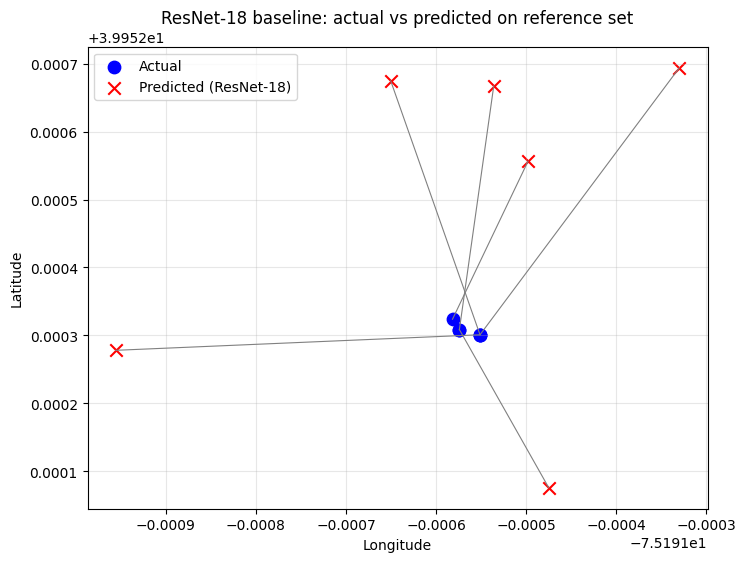

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(all_actuals[:, 1], all_actuals[:, 0], label='Actual', color='blue', s=80)
plt.scatter(all_preds[:, 1], all_preds[:, 0], label='Predicted (ResNet-18)', color='red', s=80, marker='x')
for i in range(len(all_actuals)):
    plt.plot([all_actuals[i, 1], all_preds[i, 1]],
             [all_actuals[i, 0], all_preds[i, 0]], color='gray', linewidth=0.8)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('ResNet-18 baseline: actual vs predicted on reference set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()